In [ ]:
%matplotlib inline

In [34]:
#Importing Needed Libraries
import glob
import cv2
import numpy as np
from pylablib.devices import Thorlabs
from thorcam.camera import ThorCam

import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import time
import numpy as np
import tifffile as tf #Needed to read tif files 
import scipy

#from skimage import filters
#from skimage.measure import regionprops
#from skimage.color import rgb2gray
import imageio
from scipy.optimize import curve_fit
from skimage.feature import blob_log
import pims
import av
import pandas as pd
from pandas import DataFrame, Series  # for convenience

#Video Capture Libraries
import io
from IPython.display import Video
from fractions import Fraction
import tifffile

#Trackpy libraries
import trackpy as tp


In [2]:
#Defining the functions used to track the particle
#2D Gaussian
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, offset):
    x, y = xy
    g = offset + amplitude * np.exp(-(((x - xo)**2) / (2 * sigma_x**2) + ((y - yo)**2) / (2 * sigma_y**2)))
    
    # Flattening to a 1D arra6
    return g.ravel()

def track_particles(image, limit, expected_radius):
    #use blob to detect the particles
    blobs = blob_log(image, min_sigma=2, max_sigma=expected_radius, num_sigma=5, threshold=limit)
    
    subpixel_centers = []
    
    for blob in blobs:
        y_int, x_int, radius = blob
        x_int, y_int = int(x_int), int(y_int)
        
        #Considering boundary conditions
        box_size = int(expected_radius * 1.5) 
        
        if (y_int - box_size < 0 or y_int + box_size >= image.shape[0] or 
            x_int - box_size < 0 or x_int + box_size >= image.shape[1]):
            continue
            
        roi = image[y_int - box_size : y_int + box_size, x_int - box_size : x_int + box_size]
        
        x = np.arange(x_int - box_size, x_int + box_size)
        y = np.arange(y_int - box_size, y_int + box_size)
        x_grid, y_grid = np.meshgrid(x, y)
        
        #Applying initial conditions
        guess_sigma = expected_radius / 2.0
        initial_guess = (roi.max() - roi.min(), x_int, y_int, guess_sigma, guess_sigma, roi.min())
        
        try:
            popt, _ = curve_fit(
                gaussian_2d, 
                (x_grid, y_grid), 
                roi.ravel(), 
                p0=initial_guess,
                bounds=([0, x_int-box_size, y_int-box_size, 0.1, 0.1, 0], 
                        [np.inf, x_int+box_size, y_int+box_size, box_size, box_size, np.inf])
            )
            
            subpixel_centers.append((popt[1], popt[2]))
            
        except RuntimeError:
            continue
            
    return subpixel_centers


In [ ]:
#Checking that the code can actually open the camera
with Thorlabs.ThorlabsTLCamera(serial="36826") as cam:
    cam.setup_acquisition(nframes=100)
    print("Successfully connected! :D")

In [ ]:
#Initialising the Camera

#Making sure the correct camera is being found
# List all recognized cameras first
camera_serials = Thorlabs.list_cameras_tlcam()
print("Available cameras:", camera_serials)

#Capturing the camera image
if camera_serials:
    target_serial = camera_serials[0] # extracting the serial number of the camera we actually want
    with Thorlabs.ThorlabsTLCamera(serial=target_serial) as cam:
        cam.setup_acquisition(nframes=100) # This allocates the frame buffer size
        cam.start_acquisition() #This starts the aquisition of camera data
        timeout_sec = 10.0 # Introducing a timeout
        start_time = time.time()
        while time.time() - start_time < timeout_sec:
            try:
                cam.wait_for_frame()
                frame = cam.read_newest_image()
                if frame is None:
                    continue #this is so that the code doesn't error when the next frame hasn't arrived yet
                print("Captured frame shape:", frame.shape)
                # Convert to NumPy array (already NumPy in pylablib)
                image_base = np.array(frame, dtype=np.uint16)
                image=np.squeeze(image_base)
                plt.figure()
                plt.xticks([]) 
                plt.yticks([])
                plt.imshow(image, cmap='gray')
                figure_name = f"frame_{int(time.time())}.png"
                plt.savefig(figure_name) #saving each figure with a unique figure name
                plt.show()
            except Exception as e:
                print("An error has occurred during capture:", e)
    
        cam.stop_acquisition()
else:
    print("No camera found :(")


#Extracting pixel statistics

print(image)
# Compute pixel statistics
mean_val = np.mean(image)
min_val = np.min(image)
max_val = np.max(image)
std_val = np.std(image)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(image)
print("\nPixel Statistics:")
print(f"  Mean: {mean_val:.2f}")
print(f"Min pixel value: {min_val} at {min_loc}")
print(f"Max pixel value: {max_val} at {max_loc}")
print(f"  Std Dev: {std_val:.2f}")

In [3]:
#frames= pims.PyAVReaderIndexed(r'C:\Users\classes\Documents\trap_260709_181405_705\trap_0001.mp4')#Copy the video file path here
#frames= pims.PyAVReaderIndexed(r'C:\Users\classes\Documents\trap_260709_181728_252\trap_0002.mp4')
#frames= tf.imread(r'C:\Users\classes\Optical Trapping\Camera\Video 003.tif')
raw_tiff_data = tifffile.imread(r'C:\Users\classes\Documents\trap+fixed-153Hz_260713_185008_365\trap+fixed-153Hz_0002-20260713_185008_438.tif')
frames = []

# Checking the dimensionality of the raw tif file and making a new set of frames because tif hates me
if raw_tiff_data.ndim == 2:
    frames.append(raw_tiff_data.copy())

elif raw_tiff_data.ndim == 3:
    for f in range(raw_tiff_data.shape[0]):
        frames.append(raw_tiff_data[f, :, :].copy()) 

elif raw_tiff_data.ndim == 4:
    for f in range(raw_tiff_data.shape[0]):
        frames.append(raw_tiff_data[f, :, :, 0].copy())



images = frames #setting images=frames helps later when we refer to frames as images 
print(f"number of frames= {len(frames)} ")

number of frames= 2076 


In [4]:
frames

[array([[398, 447, 441, ..., 367, 400, 324],
        [399, 432, 451, ..., 391, 400, 332],
        [382, 412, 404, ..., 395, 362, 374],
        ...,
        [411, 419, 441, ..., 319, 347, 378],
        [455, 466, 467, ..., 370, 390, 340],
        [467, 442, 480, ..., 358, 352, 335]], dtype=uint16),
 array([[417, 460, 449, ..., 369, 328, 365],
        [444, 442, 365, ..., 360, 378, 332],
        [425, 420, 420, ..., 373, 384, 412],
        ...,
        [456, 451, 402, ..., 324, 363, 331],
        [408, 414, 414, ..., 310, 384, 341],
        [437, 478, 472, ..., 340, 338, 324]], dtype=uint16),
 array([[392, 386, 437, ..., 369, 364, 372],
        [408, 433, 470, ..., 365, 360, 344],
        [461, 414, 401, ..., 388, 345, 361],
        ...,
        [446, 439, 480, ..., 416, 342, 341],
        [421, 437, 449, ..., 332, 333, 350],
        [446, 467, 423, ..., 349, 373, 342]], dtype=uint16),
 array([[436, 400, 417, ..., 395, 349, 354],
        [398, 458, 475, ..., 354, 362, 384],
        [415,

In [ ]:
# Test Data
sensor_data = np.random.normal(0.05, 0.01, (100, 100))

# Placing a fake particle
x_grid, y_grid = np.meshgrid(np.arange(100), np.arange(100))
synthetic_particle = gaussian_2d((x_grid, y_grid), amplitude=0.8, xo=24.3, yo=67.8, sigma_x=1.5, sigma_y=1.5, offset=0)
sensor_data += synthetic_particle.reshape(100, 100)


centers = track_particles(sensor_data,2,1) #Note: a test value has been arbitrarily used for the threshold here


print(f"Fitted Coordinates (X, Y): {centers[0][0]:.3f}, {centers[0][1]:.3f}")

plt.imshow(sensor_data, cmap='gray')
for (x, y) in centers:
    plt.plot(x, y, 'r+', markersize=15, label="Fitted Center")
plt.title("Particle Tracking via Gaussian Fit")
plt.legend()
plt.show()

In [5]:
'''
#Setting up an image array
images = []
for i, image in enumerate(frames):
    images.append(image[:, :, 0]) #for non-tif files
    #images.append(image[:,0]) #for tif files

'''
%matplotlib inline
#matplotlib.use('Agg') #Suppressing plots to display in a video format
import matplotlib
#Setting up for saving the frames as a video
output_memory_file = io.BytesIO()
output = av.open(output_memory_file, 'w', format="mp4")

fps=34.81

stream = output.add_stream('h264', Fraction(fps).limit_denominator())
stream.height = 430-62 #changed from 430-60 
stream.width = 580-78 #changed from 580-80
stream.pix_fmt ='yuv420p' #'yuv444p'
stream.options = {'crf': '17'}

#output.write_header()


images= frames #TIF ONLY!!!
#Defining an array for the particle tracking coordinates
centres_array=[]
intensity_array=[]
#Need to loop the particle tracking over all the frames
for index, i in enumerate(images):
    if index>=50:
        break
    centres_loop=track_particles(i,0.001,9)
    #Displaying the particle tracking data
    if len(centres_loop)>0:
        pass
        #print(f"Fitted Coordinates: {centres_loop[0][0]:.3f}, {centres_loop[0][1]:.3f}")
    else:
        print("._. alas no particles were found")
    centres_array.append(centres_loop)
    
    #Displaying the current image
    my_dpi = 100
    fig, ax =plt.subplots(figsize=(stream.width / my_dpi, stream.height / my_dpi), 
        dpi=my_dpi)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    plt.imshow(i, cmap='gray') 
    for (x, y) in centres_loop:
        plt.plot(x, y, 'r+', markersize=15, label="Fitted Center")
    plt.title("Particle Tracking using a Gaussian Fit")
    #plt.show()

    fig.canvas.draw()
    rgba_img = np.asarray(fig.canvas.buffer_rgba())
    annotate_img = rgba_img[:, :, :3][:, :, ::-1].astype(np.uint8)

    img_h, img_w = annotate_img.shape[0], annotate_img.shape[1]
    if img_h != stream.height or img_w != stream.width:
        annotate_img = cv2.resize(annotate_img, (stream.width, stream.height)).copy()
    final_img = av.VideoFrame.from_ndarray(annotate_img, format='bgr24')
    intensity_array.append(final_img) #This should hopefully give the pixels in the image!
    packet = stream.encode(final_img)
    if packet:
        output.mux(packet)
    #matplotlib.pyplot.close()
    plt.close(fig)
    
    

packet=stream.encode(None)
output.close()
output_memory_file.seek(0)
display(Video(output_memory_file.read(), embed=True, mimetype='video/mp4'))



#Seeing if pytracks trajectories can be used alongside the Gaussian tracking
data_array=[]

for frame_idx, centres in enumerate(centres_array):
    for blob in centres:
        r_data=np.nan
        y_data,x_data=blob
        data_array.append({'frame': frame_idx, 'x': x_data, 'y': y_data, 'r': r_data})

f=pd.DataFrame(data_array)
#f = pd.concat(tracking_data, ignore_index=True)

In [24]:
#Now plotting a histogram for each individual frame (Optimise efficiency later)
#Defining a 1D Gaussian for curve fitting
def gaussian_1d(x, A, B, x0):
    return A * np.exp(-B * (x-x0)**2)
A_array=[]
B_array=[]

#Setting up for saving the frames as a video
output_memory_file = io.BytesIO()
output = av.open(output_memory_file, 'w', format="mp4")

fps=34.81

stream = output.add_stream('h264', Fraction(fps).limit_denominator())
stream.height = 430-62 #changed from 430-60 
stream.width = 580-78 #changed from 580-80
stream.pix_fmt ='yuv420p' #'yuv444p'
stream.options = {'crf': '17'}

for index, i in enumerate(images):
    if index>=50:
        break
    fig, ax=plt.subplots()
    ax.clear # clearing the previous plot

    #producing the histogram
    x_intensity_array=i[np.array(f.iloc[:, 2]).astype(int)].ravel() 
    x_array=np.arange(0,len(x_intensity_array),1)
    #ax.hist(x_intensity_array,bins=50) # intensity distribution along the x-axis, taking intensity along y maximum
    #plt.show()

    #fitting a Gaussian distribution to the Histogram
    
    counts, bars, patches = ax.hist(x_intensity_array,bins=50, density=True) #extracting data from the histogram to use for the curve fit
    plt.xlabel('x /pixels')
    plt.ylabel('Pixel Number Density')
    bin_centres = (bars[:-1] + bars[1:]) / 2 #finding the centre of the bins
    
    #Initial guess
    initial_guess=[np.max(counts),1/(2*0.1*(bars[-1]-bars[0])**2),bin_centres[np.argmax(counts)]]                                          
    #bounds for the initial guess
    lower_bounds = [0, 0, bars[0]]
    upper_bounds = [np.max(counts) * 10, np.inf, bars[-1]]

    #curve fitting
    parameters, _ = curve_fit(gaussian_1d, bin_centres, counts, p0=initial_guess, bounds=(lower_bounds, upper_bounds)) 
    #(bars gives location, counts gives height)
    fit_A, fit_B, fit_x0 = parameters
    fit_intensity = gaussian_1d(bin_centres, fit_A, fit_B, fit_x0)

    A_array.append(fit_A)
    B_array.append(fit_B)

    ax.plot(bin_centres,fit_intensity, color='red') #plotting the curve fit

    #converting into a video
    fig.canvas.draw()
    rgba_img = np.asarray(fig.canvas.buffer_rgba())
    annotate_img = rgba_img[:, :, :3][:, :, ::-1].astype(np.uint8)

    img_h, img_w = annotate_img.shape[0], annotate_img.shape[1]
    if img_h != stream.height or img_w != stream.width:
        annotate_img = cv2.resize(annotate_img, (stream.width, stream.height)).copy()
    final_img = av.VideoFrame.from_ndarray(annotate_img, format='bgr24')
    intensity_array.append(final_img) #This should hopefully give the pixels in the image!
    packet = stream.encode(final_img)
    if packet:
        output.mux(packet)
    #matplotlib.pyplot.close()
    plt.close(fig)

packet=stream.encode(None)
output.close()
output_memory_file.seek(0)
display(Video(output_memory_file.read(), embed=True, mimetype='video/mp4'))

#Finding the average values of the fit parameters
A_average=np.average(A_array)
B_average=np.average(B_array)

print(A_average)
print(B_average)
plt.close(fig)

0.008214351546389555
0.0003236562274552929


In [25]:
#Now plotting a histogram for each individual frame (Optimise efficiency later)
#Defining a 1D Gaussian for curve fitting
def gaussian_1d(x, A, B, x0):
    return A * np.exp(-B * (x-x0)**2)
A_array=[]
B_array=[]

#Setting up for saving the frames as a video
output_memory_file = io.BytesIO()
output = av.open(output_memory_file, 'w', format="mp4")

fps=34.81

stream = output.add_stream('h264', Fraction(fps).limit_denominator())
stream.height = 430-62 #changed from 430-60 
stream.width = 580-78 #changed from 580-80
stream.pix_fmt ='yuv420p' #'yuv444p'
stream.options = {'crf': '17'}

for index, i in enumerate(images):
    if index>=50:
        break
    fig, ax=plt.subplots()

    #producing the histogram
    y_intensity_array=i[np.array(f.iloc[:, 2]).astype(int)].ravel() 
    y_array=np.arange(0,len(y_intensity_array),1)
    #ax.hist(y_intensity_array,bins=50) # intensity distribution along the x-axis, taking intensity along y maximum
    #plt.show()

    #fitting a Gaussian distribution to the Histogram
    
    counts_y, bars_y, patches_y = ax.hist(y_intensity_array,bins=50, density= True) #extracting data from the histogram to use for the curve fit
    plt.xlabel('y /pixels')
    plt.ylabel('Pixel Number Density')
    bin_centres_y = (bars_y[:-1] + bars_y[1:]) / 2 #finding the centre of the bins
    
    #Initial guess
    initial_guess=[np.max(counts_y),1/(2*0.1*(bars_y[-1]-bars_y[0])**2),bin_centres[np.argmax(counts)]]                                          
    #bounds for the initial guess
    lower_bounds = [0, 0, bars_y[0]]
    upper_bounds = [np.max(counts) * 10, np.inf, bars_y[-1]]

    #curve fitting
    parameters_y, _ = curve_fit(gaussian_1d, bin_centres_y, counts_y, p0=initial_guess, bounds=(lower_bounds, upper_bounds)) 
    #(bars gives location, counts gives height)
    fit_A_y, fit_B_y, fit_x0_y = parameters_y
    fit_intensity_y = gaussian_1d(bin_centres_y, fit_A_y, fit_B_y, fit_x0_y)

    A_array.append(fit_A)
    B_array.append(fit_B)

    ax.plot(bin_centres_y,fit_intensity_y, color='red') #plotting the curve fit

    #converting into a video
    fig.canvas.draw()
    rgba_img = np.asarray(fig.canvas.buffer_rgba())
    annotate_img = rgba_img[:, :, :3][:, :, ::-1].astype(np.uint8)

    img_h, img_w = annotate_img.shape[0], annotate_img.shape[1]
    if img_h != stream.height or img_w != stream.width:
        annotate_img = cv2.resize(annotate_img, (stream.width, stream.height)).copy()
    final_img = av.VideoFrame.from_ndarray(annotate_img, format='bgr24')
    intensity_array.append(final_img) #This should hopefully give the pixels in the image!
    packet = stream.encode(final_img)
    if packet:
        output.mux(packet)
    #matplotlib.pyplot.close()
    plt.close(fig)

packet=stream.encode(None)
output.close()
output_memory_file.seek(0)
display(Video(output_memory_file.read(), embed=True, mimetype='video/mp4'))

#Finding the average values of the fit parameters
A_average=np.average(A_array)
B_average=np.average(B_array)

print(A_average)
print(B_average)

0.008071145231055073
0.00031112529945079054


In [35]:
'''
#Need to convert intensity into a numpy array and extract a frame to analyse the intensity for
intensity_array_final=[frames.to_ndarray(format='gray').mean() for frames in intensity_array]

#Plotting a proabability Histogram
plt.hist(f.iloc[:, 1].values,bins=50, weights=intensity_array_final) # intensity distribution along the x-axis
plt.show()
plt.hist(f.iloc[:, 2].values,bins=50, weights=intensity_array_final) # intensity distribution along the y-axis
plt.show()
'''
#Generating the frequency array
N=len(f.iloc[:,0])
T=1/fps
freq = np.fft.fftfreq(N, d=T)

#Finding the power spectral density
(freq, S)= scipy.signal.welch(signal, 1/T, nperseg=4*1024)

plt.semilogy(freq, S)
plt.xlim([0, 100])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

NameError: name 'signal' is not defined

In [26]:
#Obtaining 

t = tp.link(f, 5)

#Removing unneeded trajectories
t1 = tp.filter_stubs(t, 25)

#Comparing the effect of filtering
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())

Frame 49: 3 trajectories present.
Before: 38
After: 0


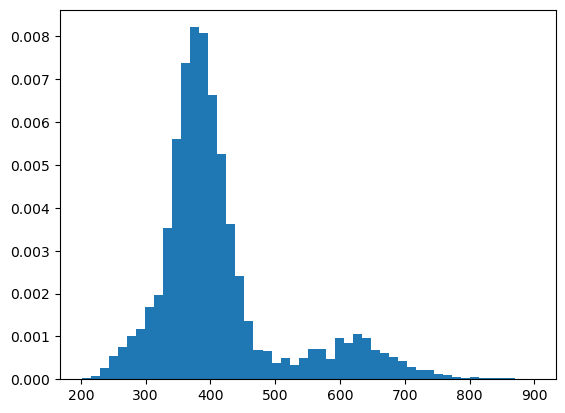

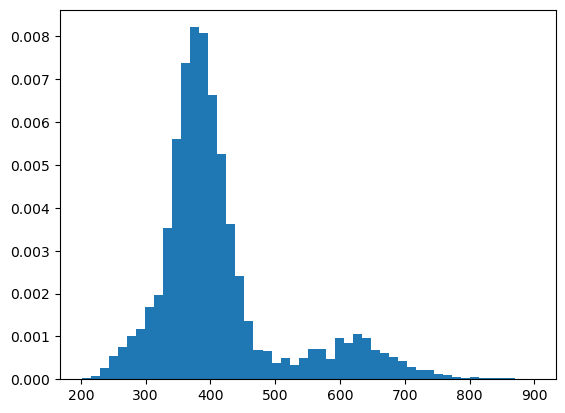

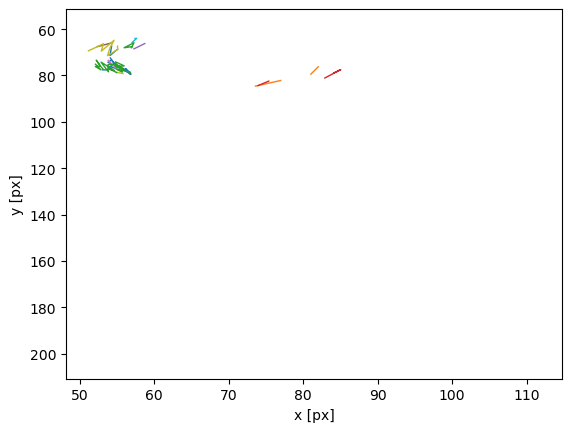

In [27]:
#Plotting the trajectories
plt.figure()
tp.plot_traj(t);

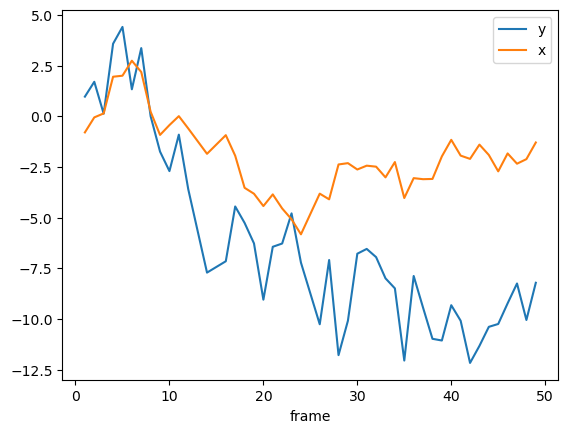

In [28]:
d = tp.compute_drift(t)
d.plot()
plt.show()

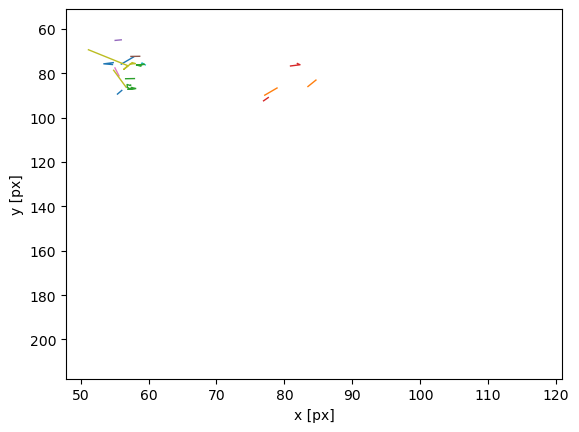

In [29]:
tm = tp.subtract_drift(t.copy(), d)
ax = tp.plot_traj(tm)
plt.show()

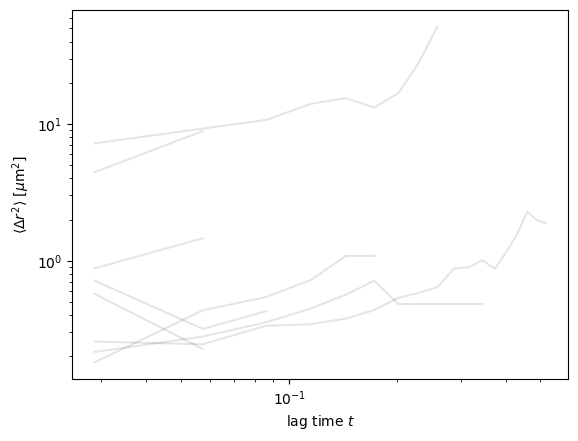

In [30]:
#Finding and plotting the mean squared displacement
im = tp.imsd(tm, (1/0.0345)*0.0278, 34.81)  # microns per pixel = 100/285., frames per second = 24
fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

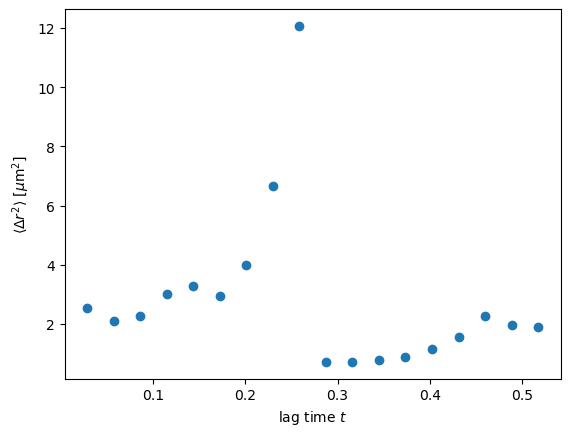

In [31]:
#Finding the ensemble mean squared displacement of all particles
em = tp.emsd(tm, (1/0.0345)*0.0278, 34.81) # microns per pixel = (from calibration calculation), frames per second = 34.81 (from camera)

#Plotting the ensemble mean displacement
fig, ax = plt.subplots()
ax.plot(em.index, em, 'o')
#ax.set_xscale('log')
#ax.set_yscale('log') (cannot set a log scale in this case due to how small the displacements are
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
#ax.set(ylim=(1e-2, 10)); (this sets a ylim, also removing this due to the small size of the displacements
plt.show()